<a href="https://colab.research.google.com/github/ChinthakindhiNishitha/DeepLearining/blob/main/week4_(types_of_GD).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Implement the MLP using the Types of GD (BGD,SGD,Mini BatchGD, SGD with Momentum, SGD with Nesterov,Adagrad, RMSProp,Adadelta and Adam) for learning XOR operation.Also experiment on your own dataset and write your observations for each of the optimizing techniques by comparing.


In [ ]:
import h5py
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# Dataset paths
train_path = "/content/drive/MyDrive/Signs_Data_Training.h5"
test_path = "/content/drive/MyDrive/Signs_Data_Testing.h5"

# Load training data
with h5py.File(train_path, "r") as train_dataset:
    X_train = np.array(train_dataset["train_set_x"])
    Y_train = np.array(train_dataset["train_set_y"])

# Load testing data
with h5py.File(test_path, "r") as test_dataset:
    X_test = np.array(test_dataset["test_set_x"])
    Y_test = np.array(test_dataset["test_set_y"])

# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

# Flatten images for MLP
X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)

# One-hot encoding
Y_train = tf.keras.utils.to_categorical(Y_train, 6)
Y_test = tf.keras.utils.to_categorical(Y_test, 6)

In [ ]:
def create_mlp():
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(6, activation='softmax')
    ])
    return model

In [ ]:
optimizers = {
    "Batch GD": tf.keras.optimizers.SGD(learning_rate=0.01),
    "SGD": tf.keras.optimizers.SGD(learning_rate=0.01),
    "Mini Batch GD": tf.keras.optimizers.SGD(learning_rate=0.01),
    "Momentum": tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    "Nesterov": tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9, nesterov=True),
    "Adagrad": tf.keras.optimizers.Adagrad(learning_rate=0.01),
    "RMSProp": tf.keras.optimizers.RMSprop(learning_rate=0.001),
    "Adadelta": tf.keras.optimizers.Adadelta(),
    "Adam": tf.keras.optimizers.Adam(learning_rate=0.001)
}

In [ ]:
results = {}

for name, optimizer in optimizers.items():

    print("\nTraining with:", name)

    model = create_mlp()

    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        X_train,
        Y_train,
        epochs=15,
        batch_size=32,
        validation_split=0.2,
        verbose=0
    )

    test_loss, test_acc = model.evaluate(X_test, Y_test, verbose=0)

    results[name] = test_acc


Training with: Batch GD


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training with: SGD

Training with: Mini Batch GD

Training with: Momentum

Training with: Nesterov

Training with: Adagrad

Training with: RMSProp

Training with: Adadelta

Training with: Adam


Batch GD Test Accuracy: 0.4000000059604645
SGD Test Accuracy: 0.3499999940395355
Mini Batch GD Test Accuracy: 0.25833332538604736
Momentum Test Accuracy: 0.1666666716337204
Nesterov Test Accuracy: 0.1666666716337204
Adagrad Test Accuracy: 0.4000000059604645
RMSProp Test Accuracy: 0.3083333373069763
Adadelta Test Accuracy: 0.3083333373069763
Adam Test Accuracy: 0.574999988079071


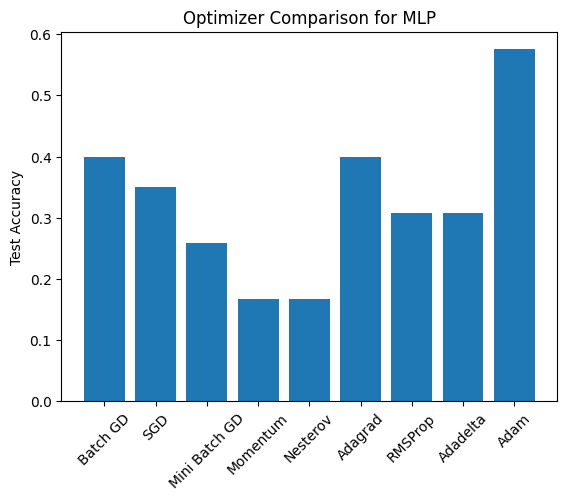

In [ ]:
for opt, acc in results.items():
    print(opt, "Test Accuracy:", acc)
names = list(results.keys())
values = list(results.values())

plt.bar(names, values)
plt.xticks(rotation=45)
plt.ylabel("Test Accuracy")
plt.title("Optimizer Comparison for MLP")
plt.show()